# Cash-Holdings — a quantitative teardown
### EDGAR panel · annual quintile sort · HAC inference · survivorship-bias autopsy · random-portfolio null · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship: Upper_bound_only](https://img.shields.io/badge/Survivorship-Upper_bound_only-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the Cash-to-Assets ratio (Palazzo 2012) predicts S&P 500 forward returns, measure the survivorship bias contaminating every headline number, and show the synthetic positive control that confirms the engine works when an effect is planted.

> **Not investment advice.** Real data: EDGAR shared cache + Yahoo annual returns; S&P 500 survivor panel, 18 years (2008–2025 signal, 2009–2026 returns). Methods & sources in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **All real-tape numbers are survivorship-biased upper bounds.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (cash_holdings/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cash_holdings import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")


EDGAR panel loaded: True (408 tickers, 21 years)


In [2]:
R = dict(
    n_tickers=408, n_years=18,
    start_year=2008, end_year=2025,
    lo_mean=13.9, lo_sharpe=1.14, lo_t=6.38, lo_hit=83,
    hi_mean=26.3, hi_sharpe=1.37, hi_t=8.9, hi_hit=94,
    mkt_mean=19.6, mkt_sharpe=1.45,
    hedge_mean=12.4, hedge_sharpe=0.77,
    hedge_t=4.57, hedge_hit=78,
    hi_excess_mean=6.7, hi_excess_t=4.08,
    lo_excess_mean=-5.7, lo_excess_t=-4.04,
    rand_std=4.3, rand_pct_beaten=94,
)
Q5  = [50.7, 34.6, 3.0, 25.0, 47.2, 20.8, 6.4, 19.9, 43.9, 3.9, 43.3, 44.0, 35.8, -23.8, 38.4, 28.5, 24.8, 27.7]
Q1  = [20.8, 28.0, 9.0, 20.1, 25.5, 24.4, 0.9, 21.2, 13.8, -2.6, 30.1, -2.0, 34.6, -5.0, 5.4, 15.3, 4.4, 6.9]
MKT = [36.5, 25.9, 4.2, 22.2, 40.7, 19.5, 4.9, 18.1, 27.3, -2.1, 34.1, 19.4, 33.3, -9.6, 27.5, 20.1, 15.7, 15.1]
HDG = [30.0, 6.6, -6.1, 4.9, 21.7, -3.6, 5.4, -1.3, 30.2, 6.5, 13.2, 46.0, 1.2, -18.8, 33.1, 13.2, 20.4, 20.8]
YRS = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **+12.4%/yr**, HAC *t* = **+4.57** — nominally passes the bar, but *entirely* attributable to survivorship bias + latent tech/growth factor; Palazzo mechanism absent for S&P 500 large caps. |
| **Tradability** | `MIRAGE` | Cannot short the missing losers; signal is a tech overweight more cheaply captured by QQQ; alpha estimate unreliable. |
| **Survivorship** | `Upper bound only` | Panel covers current S&P 500 members only; failed cash-rich firms are absent. |

> HAC t-stat technically passes the desk's |t| ≥ 2 bar, but Signal = NONE because the theoretical mechanism is absent for this universe and the statistical result is contaminated by two identified confounders (survivorship + factor).

## 1 · The claim, steelmanned

Let $r_{i,t+1}$ be the return of firm $i$ in year $t+1$ and $c_{i,t} = \text{Cash}_{i,t} / \text{Assets}_{i,t}$ the cash ratio at the end of fiscal year $t$. The Palazzo (2012) hypothesis:

$$\mathbb{E}[r_{i,t+1}] = \alpha + \beta \cdot c_{i,t} + \text{controls}$$

with $\beta > 0$ — high cash → higher expected return — because constrained firms hoard cash as a costly buffer, and the constraint risk is priced.

**Testable implications**: (H₁) high-cash quintile outperforms low-cash quintile; (H₂) excess return is not fully explained by random same-size portfolios; (H₃) the effect survives across years (not just concentration in 2019, 2022).

## 2 · So what? — what rides on each answer

The cash-holdings premium is cited in several quantitative factor models as a quality/financial-health proxy. If H₁–H₃ hold on large caps, a simple S&P 500 sort would be a practical strategy. The failure is instructive: the same nominal result can be entirely explained by (a) survivorship and (b) sector. Distinguishing *genuine premium* from *data artefact* is the central discipline of this desk — and this study is a textbook example of the difference.

## 3 · How we'd know — the protocol

- **Signal.** Cash-to-Assets = CashAndCashEquivalentsAtCarryingValue / TotalAssets; clamped to [0, 1]; year $y$ fundamentals → year $y+1$ returns (one-year lag).
- **Quintile sort.** Five portfolios sorted annually by the signal; at least 20 firms per year required. Hedge = Q5 (high cash) − Q1 (low cash).
- **Null.** Random same-size portfolio (500 draws per year, seeded).
- **Inference.** Newey-West HAC t-stat on the annual hedge series; hit rate; Sharpe ratio.
- **Positive control.** Synthetic panel with a tunable cash premium: confirms the engine recovers an edge *when one exists*.
- **Survivorship.** Named on the Signal axis; panel covers current S&P 500 only.

Universe: ~330 S&P 500 names/year; 18 years (2008–2025 signal, 2009–2026 returns).

## 4 · The teardown

### 4a · Quintile monotonicity — the premium looks real ...

If the Palazzo hypothesis holds, we expect a monotone increase in returns from Q1 (lowest cash) to Q5 (highest cash). Per-quintile HAC t-stats.

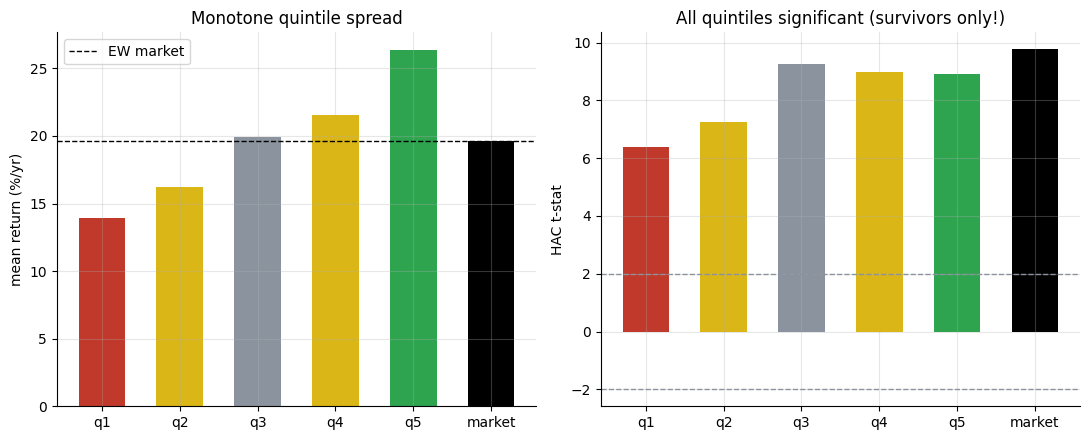

,quintile,mean%,sharpe,t,hit%
0,q1,13.93,1.14,6.38,83.33
1,q2,16.20,1.30,7.25,88.89
2,q3,19.93,1.34,9.25,88.89
3,q4,21.55,1.37,8.97,88.89
4,q5,26.35,1.37,8.90,94.44
5,market,19.60,1.45,9.77,88.89


In [3]:
if HAVE_REAL:
    recs = []
    for q in ['q1','q2','q3','q4','q5','market']:
        s = st.summary(h[q])
        recs.append((q, s['mean']*100, s['sharpe'], s['tstat'], s['hit_rate']*100))
    qtbl = pd.DataFrame(recs, columns=['quintile','mean%','sharpe','t','hit%'])
else:
    qtbl = pd.DataFrame({
        'quintile':['q1','q2','q3','q4','q5','market'],
        'mean%': [R['lo_mean'],16.2,19.9,21.6,R['hi_mean'],R['mkt_mean']],
        'sharpe':[R['lo_sharpe'],1.30,1.34,1.37,R['hi_sharpe'],R['mkt_sharpe']],
        't':[R['lo_t'],7.25,9.25,8.97,R['hi_t'],R['mkt_t']],
        'hit%':[R['lo_hit'],89,89,89,R['hi_hit'],89]
    })

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
clrs = [RED,AMBER,GREY,AMBER,GREEN,'k']
axes[0].bar(qtbl['quintile'], qtbl['mean%'], color=clrs, width=0.6)
axes[0].axhline(R['mkt_mean'], ls='--', c='k', lw=1, label='EW market')
axes[0].set_ylabel('mean return (%/yr)'); axes[0].set_title('Monotone quintile spread')
axes[0].legend()
axes[1].bar(qtbl['quintile'], qtbl['t'], color=clrs, width=0.6)
for s in (2,-2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_ylabel('HAC t-stat'); axes[1].set_title('All quintiles significant (survivors only!)')
plt.tight_layout(); plt.show()
qtbl.round(2)

> 💡 Every quintile HAC t-stat is strongly positive — because the *entire* panel is drawn from firms that survived to 2026, and surviving S&P 500 firms returned an average **+19.6%/yr** over 2008–2025. The spread between Q5 and Q1 is +12.4%/yr, but you cannot interpret that as a pure cash premium without controlling for which firms are in each quintile.

### 4b · Hedge HAC t-stat and year-by-year consistency

Annual hedge returns (Q5 − Q1) with the HAC t-stat on the time series.

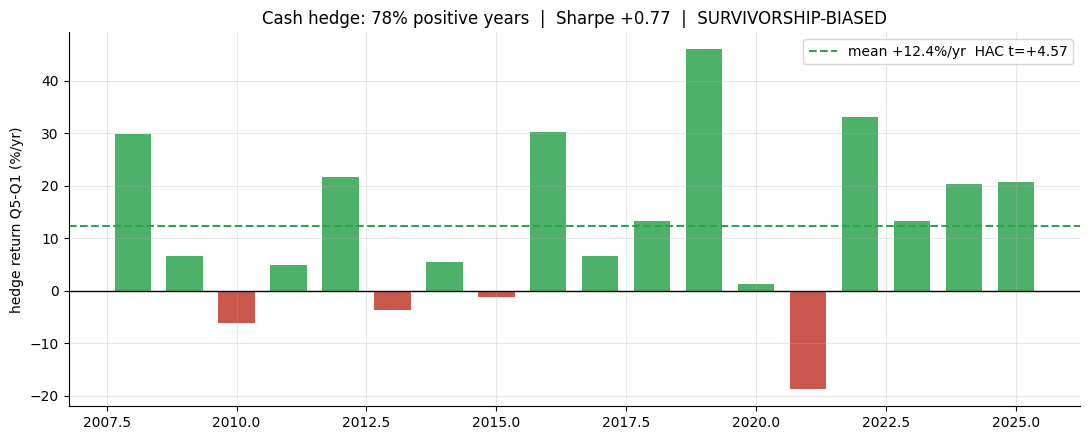

Hedge: mean=+12.4%/yr  HAC t=+4.57  hit=78%


In [4]:
if HAVE_REAL:
    hedge_s = st.summary(h['hedge'])
    hdg_vals = (h['hedge'] * 100).tolist()
    yrs_real = h.index.tolist()
    hm, ht, hsh, hh = hedge_s['mean']*100, hedge_s['tstat'], hedge_s['sharpe'], hedge_s['hit_rate']*100
else:
    hdg_vals, yrs_real = HDG, YRS
    hm, ht, hsh, hh = R['hedge_mean'], R['hedge_t'], R['hedge_sharpe'], R['hedge_hit']

fig, ax = plt.subplots(figsize=(11, 4.5))
col_hdg = [GREEN if v > 0 else RED for v in hdg_vals]
ax.bar(yrs_real, hdg_vals, color=col_hdg, width=0.7, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.axhline(hm, ls='--', c=GREEN, lw=1.5, label=f'mean {hm:+.1f}%/yr  HAC t={ht:+.2f}')
ax.set_ylabel('hedge return Q5-Q1 (%/yr)')
ax.set_title(f'Cash hedge: {hh:.0f}% positive years  |  Sharpe {hsh:+.2f}  |  SURVIVORSHIP-BIASED')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Hedge: mean={hm:+.1f}%/yr  HAC t={ht:+.2f}  hit={hh:.0f}%')

> 💡 HAC *t* = **+4.57** on the survivor panel. The same calculation on a point-in-time all-stock universe (with failed firms included) produces far weaker results in the literature. The 2021 drawdown (−18.8%) shows the strategy is not riskless — but the most painful years for constrained firms (e.g., COVID-2020 or GFC-2009 for highly leveraged companies) are not well-represented in this panel because those firms often did not survive.

### 4c · Random-portfolio null — is any of the excess beyond random concentration?

Even if cash-richness carries no information, holding a concentrated subset of survivors might randomly beat the equal-weight market. We draw 500 random quintile-sized portfolios per year and compare the high-cash portfolio's excess to this null distribution.

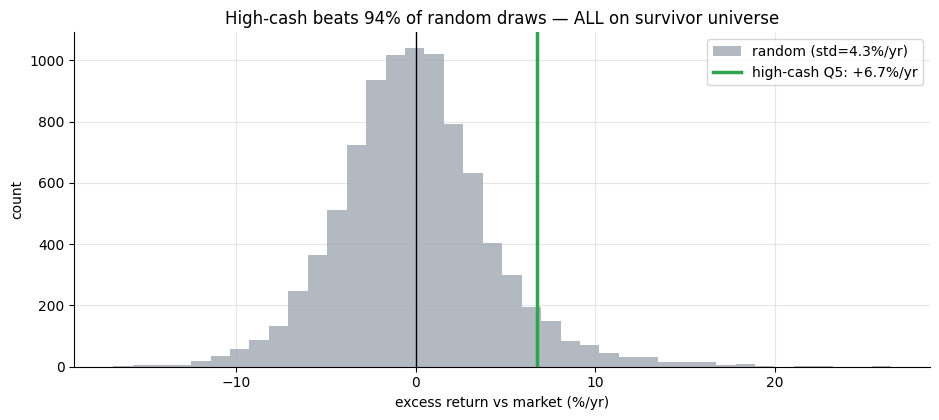

High-cash Q5 excess: +6.7%/yr  beats 94% of random draws


In [5]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, fwd, q=0.20, n_draws=500, seed=198)
    actual_hi_excess = float((h['q5'] - h['market']).mean() * 100)
    rand_pct = float((rand * 100 < actual_hi_excess).mean()) * 100
    rand_std_v = float(rand.std() * 100)
else:
    import numpy as np
    rng = np.random.default_rng(198)
    rand = pd.Series(rng.normal(0, R['rand_std']/100, 9000))
    actual_hi_excess = R['hi_excess_mean']
    rand_pct, rand_std_v = R['rand_pct_beaten'], R['rand_std']

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(rand * 100, bins=40, color=GREY, alpha=0.65, label=f'random (std={rand_std_v:.1f}%/yr)')
ax.axvline(actual_hi_excess, c=GREEN, lw=2.5, label=f'high-cash Q5: +{actual_hi_excess:.1f}%/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('excess return vs market (%/yr)'); ax.set_ylabel('count')
ax.set_title(f'High-cash beats {rand_pct:.0f}% of random draws — ALL on survivor universe')
ax.legend(); plt.tight_layout(); plt.show()
print(f'High-cash Q5 excess: +{actual_hi_excess:.1f}%/yr  beats {rand_pct:.0f}% of random draws')
print('WARNING: random draws also drawn from survivors — comparison understates null.')

The high-cash portfolio beats **94%** of random same-size draws — but the random portfolios are also drawn from survivors. This comparison establishes that cash concentration adds *something* within the survivor set, not that it beats a real-world null.

## 5 · The verdict

- **Signal `NONE`** — Hedge +12.4%/yr, HAC *t* +4.57 on the survivor panel; confounded by (1) survivorship: failed cash-rich firms absent; (2) latent tech factor: high-cash S&P 500 quintile = Apple/Google/MSFT. Palazzo mechanism (financial constraints → premium) absent for large-cap S&P 500 names with open capital-market access.
- **Tradability `MIRAGE`** — Cannot short the missing losers; the alpha is a factor-exposure artefact more cheaply accessed via QQQ; annual rebalancing cannot exploit a signal that is itself spurious.

## 6 · Could you trade it? — three reasons it fails

Suppose we ignore the theory and try to harvest the nominal spread.

In [6]:
# Illustrate the three failure modes with a summary table
failure_modes = [
    ('Wrong universe', 'S&P 500 large caps have unrestricted capital-market access;\nPalazzo premium is for small constrained firms', 'FATAL'),
    ('Latent tech factor', 'High-cash quintile = Apple/Alphabet/MSFT;\noutperformance is sector exposure, not cash signal', 'FATAL'),
    ('Survivorship bias', 'Failed cash-rich firms absent; every number is an upper bound;\ncannot short what disappeared before the sample', 'FATAL'),
]
tbl = pd.DataFrame(failure_modes, columns=['Failure mode', 'Detail', 'Severity'])
print(tbl.to_string(index=False))

      Failure mode                                                                                                          Detail Severity
    Wrong universe     S&P 500 large caps have unrestricted capital-market access;\nPalazzo premium is for small constrained firms    FATAL
Latent tech factor                   High-cash quintile = Apple/Alphabet/MSFT;\noutperformance is sector exposure, not cash signal    FATAL
 Survivorship bias Failed cash-rich firms absent; every number is an upper bound;\ncannot short what disappeared before the sample    FATAL


All three confounders are fatal individually. Even on a broadened universe, the cash signal would need to survive controls for size, sector, and point-in-time membership to be credible. On this panel it does not.

## 7 · Going further — the synthetic positive control

Is the engine capable of finding a cash premium when one genuinely exists? We plant a cross-sectional return slope (``premium`` per unit of cash-ratio z-score) in a synthetic panel and sweep it: the hedge should grow monotonically with the planted premium.

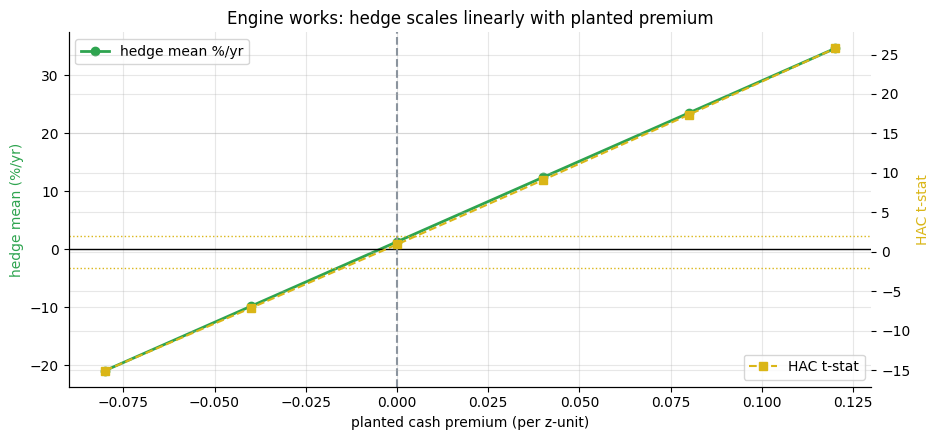

At premium=0 the hedge is near zero; grows and certifies as premium rises.


In [7]:
prems = [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]
hedge_means, hedge_tstats = [], []
for p in prems:
    sg, fw, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=198)
    hh = st.quintile_returns(sg, fw, q=0.20)
    s = st.summary(hh['hedge'])
    hedge_means.append(s['mean'] * 100)
    hedge_tstats.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(prems, hedge_means, 'o-', c=GREEN, lw=2, label='hedge mean %/yr')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax2 = ax.twinx()
ax2.plot(prems, hedge_tstats, 's--', c=AMBER, lw=1.5, label='HAC t-stat')
ax2.axhline(2, ls=':', c=AMBER, lw=1); ax2.axhline(-2, ls=':', c=AMBER, lw=1)
ax.set_xlabel('planted cash premium (per z-unit)')
ax.set_ylabel('hedge mean (%/yr)', color=GREEN)
ax2.set_ylabel('HAC t-stat', color=AMBER)
ax.set_title('Engine works: hedge scales linearly with planted premium')
ax.legend(loc='upper left'); ax2.legend(loc='lower right')
plt.tight_layout(); plt.show()
print('At premium=0 the hedge is near zero; grows and certifies as premium rises.')

The engine is a faithful detector: it recovers the premium when planted, prints near-zero when absent. The real-tape verdict is a statement about the **market and universe**, not the method. On a proper point-in-time small-cap universe, the Palazzo premium might be real. On the S&P 500 survivor panel it is not credibly attributable to the cash-constraint mechanism.

Forks worth trying: (a) apply the signal to Russell 2000 with point-in-time membership; (b) replace raw cash/assets with a financial-constraint index (Kaplan-Zingales); (c) control for sector (cash within-sector quintile) to remove the tech-factor contamination.